In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score, f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from runs import multi_subject_experiments, test_experiments
import os
import pickle as pkl
from utils_multisubject import read_files, apply_features, create_window_df

In [150]:
# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]

# Features To Remove
remove_features = []

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]
final_labels = {"discrete": "discrete_label",
            "binary": "binary_label",
            "continuous": "continuous_label"}

In [151]:
# Chosen Experiment from runs.py
experiment_number = 5

# Save Model Metrics
save_results = True

# Load Windowed Data
seconds = 7 # Duration of each window in seconds
window_size = int(seconds*5.25)
windowedData = []

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

participants = str(participant_list)
conditions = str(conditions_list)[2:-2]

print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [2, 5, 6, 9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 24] 
Training Conditions:  RW


In [152]:
# Remove Random Participants for Cross-Validation
number_of_participants = len(participant_list)

number_of_participants_for_validation = number_of_participants // 5

random_indices = np.random.choice(number_of_participants, 
                                   number_of_participants_for_validation,
                                   replace=False)

train_participants = [participant_list[i] for i in range(number_of_participants) if i not in random_indices]
validation_participants = [participant_list[i] for i in random_indices]

print("Validation Participants: ", validation_participants)
print("Training Participants: ", train_participants)


Validation Participants:  [5, 2]
Training Participants:  [6, 9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 24]


In [153]:
# Read Files for Training Data
train_data = read_files(participant_list=train_participants, source_folder_1 = source_folder, conditions=conditions_list)
val_data = read_files(participant_list=validation_participants, source_folder_1 = source_folder, conditions=conditions_list)

df_data_train = pd.DataFrame()
df_labels_train = pd.DataFrame()

for key in train_data.keys():
    window_data, window_labels = create_window_df(train_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
    print(key, "is done")
    df_data_train = pd.concat([df_data_train, window_data], ignore_index=True)
    df_labels_train = pd.concat([df_labels_train, window_labels], ignore_index=True)

['discrete_optimal', 'binary_optimal', 'continuous_optimal']
11RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
17RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
24RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
19RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
9RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
15RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
18RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
16RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
6RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
20RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
10RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
13RW is done


In [154]:
df_data_train.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)

df_data_val = pd.DataFrame()
df_labels_val = pd.DataFrame()

for key in val_data.keys():
    window_data, window_labels = create_window_df(val_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
    print(key, "is done")
    df_data_val = pd.concat([df_data_val, window_data], ignore_index=True)
    df_labels_val = pd.concat([df_labels_val, window_labels], ignore_index=True)

df_data_val.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)
print(df_labels_val.columns)

['discrete_optimal', 'binary_optimal', 'continuous_optimal']
2RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
5RW is done
Index(['discrete_label', 'continuous_label', 'binary_label'], dtype='object')


In [155]:
def create_train_data(df_data, df_labels):
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)

    # Downsample discrete/multi-class labels
    min_discrete = df['discrete_label'].value_counts().min()
    print("Minimum count for discrete_label:", min_discrete)
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=42))

    # Downsample binary labels
    min_binary = df['binary_label'].value_counts().min()
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=42))

    # Separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return df, X_binary, X_discrete, y_binary, y_discrete, y_continuous

x_continuous, x_binary, x_discrete, y_binary, y_discrete, y_continuous = create_train_data(df_data=df_data_train, df_labels=df_labels_train)
print("Binary label counts:\n", y_binary.value_counts())
print("Discrete label counts:\n", y_discrete.value_counts())

Minimum count for discrete_label: 2382
Minimum count for binary_label: 5476
Binary label counts:
 binary_label
0    5476
1    5476
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    2382
1    2382
2    2382
Name: count, dtype: int64


In [187]:
random_state = 100
shuffle = True

test_size = 0.2

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(x_binary, y_binary, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=y_binary)
X_discrete_train, X_discrete_test, y_discrete_train, y_discrete_test = train_test_split(x_discrete, y_discrete, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=y_discrete)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(x_continuous, y_continuous, test_size=test_size, random_state=42)

print(y_binary_train.value_counts(), y_binary_test.value_counts())
print(y_discrete_train.value_counts(), y_discrete_test.value_counts())

# Remove chosen features
cols_to_keep = [col for col in X_binary_train.columns if ("mean" in col.lower() or "skewness" in col.lower() or "intercept" in col.lower() or "std" in col.lower() or "slope" in col.lower() or "kurtosis" in col.lower())]
X_binary_train = X_binary_train[cols_to_keep]
X_binary_test = X_binary_test[cols_to_keep]
x_validation_train = df_data_val[cols_to_keep]

y_binary_training = y_binary_train.reset_index(drop=True)
y_binary_test = y_binary_test.reset_index(drop=True)

binary_label
1    4381
0    4380
Name: count, dtype: int64 binary_label
0    1096
1    1095
Name: count, dtype: int64
discrete_label
1    1906
2    1905
0    1905
Name: count, dtype: int64 discrete_label
2    477
0    477
1    476
Name: count, dtype: int64


In [188]:
X_binary_train.head(1)

,L_O_DSphi_Mean,L_O_DSphi_Std,L_O_DSphi_Slope,L_O_DSphi_Intercept,L_O_DSphi_Kurtosis,L_O_DSphi_Skewness,L_D_DSphi_Mean,L_D_DSphi_Std,L_D_DSphi_Slope,L_D_DSphi_Intercept,...,R_O_DSI_Slope,R_O_DSI_Intercept,R_O_DSI_Kurtosis,R_O_DSI_Skewness,L_D_DSI_Mean,L_D_DSI_Std,L_D_DSI_Slope,L_D_DSI_Intercept,L_D_DSI_Kurtosis,L_D_DSI_Skewness
5884,6.362304,1.20329,6.655336,-24.843272,-0.964661,0.599001,-0.74078,0.280732,20.45082,32.649554,...,-20.667217,-7.142677,-1.206488,0.312089,-0.469605,0.035746,-263.941608,-106.448378,-0.219402,0.796966


### Binary Model Training

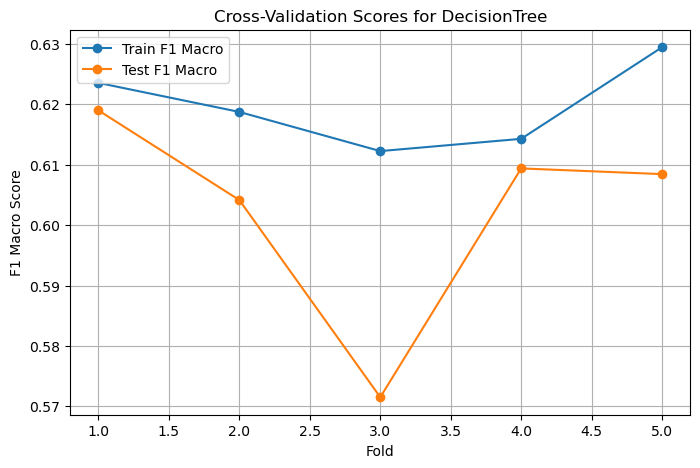

              precision    recall  f1-score   support

           0       0.57      0.69      0.62      1096
           1       0.61      0.48      0.53      1095

    accuracy                           0.58      2191
   macro avg       0.59      0.58      0.58      2191
weighted avg       0.59      0.58      0.58      2191



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.utils import shuffle

shuffle_test = False
save_binary_results = False

# RW Experiment 5 - All Features - Random 42, 12, 100
clf = DecisionTreeClassifier(
    max_depth=4,        
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)
name = "DecisionTree"

# clf = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', n_jobs=-1)
# name = "KNN"

# clf = MLPClassifier(
#     hidden_layer_sizes=(100, 50),
#     activation='relu',
#     solver='adam',
#     alpha=0.0001,
#     batch_size='auto',
#     learning_rate='constant',
#     learning_rate_init=0.001,
#     max_iter=200,
#     random_state=42)
# name = "MLP"

# clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
# name = "SVC"

# clf = RandomForestClassifier(
#     n_estimators=40,
#     max_depth=2,
#     min_samples_leaf=5,
#     max_features=0.2,
#     random_state=42)
# name = "RandomForest"

from copy import deepcopy

binary_fold_results = {"Fold": [], "Train Score": [], "Test Score": []}
binary_results_empty = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall": [],
    "Class1 Recall": [],
    "Class0 Precision": [],
    "Class1 Precision": [],
    "Class0 F1": [],
    "Class1 F1": [],
    "Macro F1": [],
    "Macro Recall": [],
    "Macro Precision": [],
    "TrainParticipants": [],
    "ValidateParticipants": [],
    "TrainConditions": [],
    "TestConditions": [],
    "Experiment": [],
}

binary_results = deepcopy(binary_results_empty)

if shuffle_test:
    y_binary_train = shuffle(y_binary_training, random_state=42)

skf_binary = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_binary_train, y_binary_train, 
    cv=skf_binary, scoring='f1_macro', 
    return_train_score=True
)

# Save cross-val results
for i, (train_score, test_score) in enumerate(zip(cv_results["train_score"], cv_results["test_score"])):
    binary_fold_results["Fold"].append(i + 1)
    binary_fold_results["Train Score"].append(train_score)
    binary_fold_results["Test Score"].append(test_score)

# Plot train and test scores
plt.figure(figsize=(8, 5))
plt.plot(binary_fold_results["Fold"], binary_fold_results["Train Score"], marker='o', label='Train F1 Macro')
plt.plot(binary_fold_results["Fold"], binary_fold_results["Test Score"], marker='o', label='Test F1 Macro')
plt.xlabel("Fold")
plt.ylabel("F1 Macro Score")
plt.title(f"Cross-Validation Scores for {name}")
plt.legend()
plt.grid(True)
plt.show()

# Refit the classifier on the full training set
clf.fit(X_binary_train, y_binary_train)

# Evaluate on the test set
y_binary_pred = clf.predict(X_binary_test)

report = classification_report(y_binary_test, y_binary_pred, output_dict=True)
print(classification_report(y_binary_test, y_binary_pred))

acc = accuracy_score(y_binary_test, y_binary_pred)
prec = precision_score(y_binary_test, y_binary_pred)
rec = recall_score(y_binary_test, y_binary_pred)
f1 = f1_score(y_binary_test, y_binary_pred)

binary_results["Classifier"].append(name)
binary_results["Accuracy"].append(acc)
binary_results["Precision"].append(prec)
binary_results["Recall"].append(rec)
binary_results["F1"].append(f1)
binary_results["Class0 Recall"].append(report['0']['recall'])
binary_results["Class1 Recall"].append(report['1']['recall'])
binary_results["Class0 Precision"].append(report['0']['precision'])
binary_results["Class1 Precision"].append(report['1']['precision'])
binary_results["Class0 F1"].append(report['0']['f1-score'])
binary_results["Class1 F1"].append(report['1']['f1-score'])
binary_results["Macro F1"].append(report['macro avg']['f1-score'])
binary_results["Macro Recall"].append(report['macro avg']['recall'])
binary_results["Macro Precision"].append(report['macro avg']['precision'])
binary_results["TrainParticipants"].append(train_participants)
binary_results["ValidateParticipants"].append(validation_participants)
binary_results["TrainConditions"].append(conditions_list)
binary_results["TestConditions"].append(conditions_list)
binary_results["Experiment"].append(experiment_number)

binary_results_df = pd.DataFrame(binary_results)

if save_binary_results:
    with open('results/models/{}/Participant{}_Condition{}_{}_binary.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
        pkl.dump(clf,f)
    if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
        binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
    else:
        binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)



### Binary Model Cross Validation

In [ ]:

binary_results_df.head(5)
val_predictions = clf.predict(x_validation_train)
binary_resultsCV = deepcopy(binary_results_empty)

report = classification_report(df_labels_val["binary_label"], val_predictions, output_dict=True)
print(classification_report(df_labels_val["binary_label"], val_predictions))

f1 = f1_score(df_labels_val["binary_label"], val_predictions)
acc = accuracy_score(df_labels_val["binary_label"], val_predictions)
recall = recall_score(df_labels_val["binary_label"], val_predictions)
prec = precision_score(df_labels_val["binary_label"], val_predictions)

binary_resultsCV["Classifier"].append(name)
binary_resultsCV["Accuracy"].append(acc)
binary_resultsCV["Precision"].append(prec)
binary_resultsCV["Recall"].append(rec)
binary_resultsCV["F1"].append(f1)
binary_resultsCV["Class0 Recall"].append(report['0']['recall'])
binary_resultsCV["Class1 Recall"].append(report['1']['recall'])
binary_resultsCV["Class0 Precision"].append(report['0']['precision'])
binary_resultsCV["Class1 Precision"].append(report['1']['precision'])
binary_resultsCV["Class0 F1"].append(report['0']['f1-score'])
binary_resultsCV["Class1 F1"].append(report['1']['f1-score'])
binary_resultsCV["Macro F1"].append(report['macro avg']['f1-score'])
binary_resultsCV["Macro Recall"].append(report['macro avg']['recall'])
binary_resultsCV["Macro Precision"].append(report['macro avg']['precision'])
binary_resultsCV["TrainParticipants"].append(train_participants)
binary_resultsCV["ValidateParticipants"].append(validation_participants)
binary_resultsCV["TrainConditions"].append(conditions_list)
binary_resultsCV["TestConditions"].append(conditions_list)
binary_resultsCV["Experiment"].append(experiment_number)

binaryCV_results_df = pd.DataFrame(binary_resultsCV)

if save_binary_results:
    if not os.path.isfile("results/data/{}_binaryCV.csv".format(experiment_name)):
            binaryCV_results_df.to_csv("results/data/{}_binaryCV.csv".format(experiment_name))
    else:
        binaryCV_results_df.to_csv("results/data/{}_binaryCV.csv".format(experiment_name), mode="a", header=False)

print(f1, acc, recall)

              precision    recall  f1-score   support

           0       0.62      0.77      0.69       861
           1       0.60      0.43      0.50       702

    accuracy                           0.61      1563
   macro avg       0.61      0.60      0.59      1563
weighted avg       0.61      0.61      0.60      1563

0.4970906068162926 0.6129238643634037 0.42592592592592593


In [183]:
poop()

NameError: name 'poop' is not defined

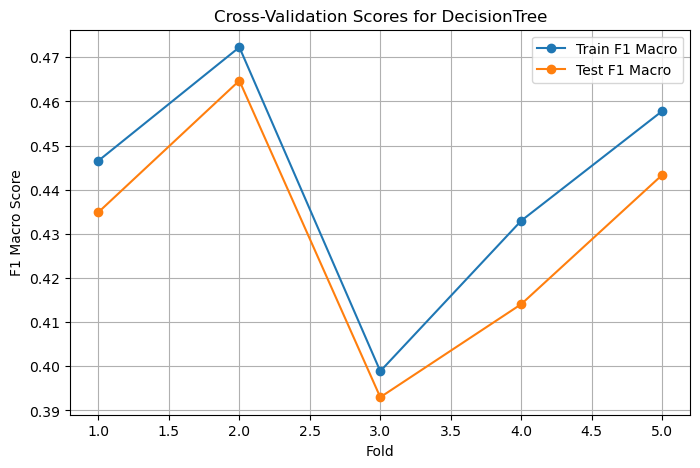

              precision    recall  f1-score   support

           0       0.40      0.60      0.48       477
           1       0.51      0.46      0.49       476
           2       0.63      0.37      0.47       477

    accuracy                           0.48      1430
   macro avg       0.51      0.48      0.48      1430
weighted avg       0.51      0.48      0.48      1430



In [191]:
from sklearn.model_selection import cross_validate
from sklearn.utils import shuffle

shuffle_test = False
save_discrete_results = True

# RW Experiment 5 - All Features - Random 42, 12, 100
clf = DecisionTreeClassifier(
    max_depth=4,        
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)
name = "DecisionTree"

# clf = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', n_jobs=-1)
# name = "KNN"

# clf = MLPClassifier(
#     hidden_layer_sizes=(100, 50),
#     activation='relu',
#     solver='adam',
#     alpha=0.0001,
#     batch_size='auto',
#     learning_rate='constant',
#     learning_rate_init=0.001,
#     max_iter=200,
#     random_state=42)
# name = "MLP"

# clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
# name = "SVC"

# clf = RandomForestClassifier(
#     n_estimators=40,
#     max_depth=2,
#     min_samples_leaf=5,
#     max_features=0.2,
#     random_state=42)
# name = "RandomForest"

from copy import deepcopy

discrete_fold_results = {"Fold": [], "Train Score": [], "Test Score": []}
discrete_results_empty = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall": [],
    "Class1 Recall": [],
    "Class0 Precision": [],
    "Class1 Precision": [],
    "Class0 F1": [],
    "Class1 F1": [],
    "Macro F1": [],
    "Macro Recall": [],
    "Macro Precision": [],
    "TrainParticipants": [],
    "ValidateParticipants": [],
    "TrainConditions": [],
    "TestConditions": [],
    "Experiment": [],
}

discrete_results = deepcopy(discrete_results_empty)

if shuffle_test:
    y_discrete_train = shuffle(y_discrete_train, random_state=42)

skf_discrete = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_discrete_train, y_discrete_train, 
    cv=skf_discrete, scoring='f1_macro', 
    return_train_score=True
)

# Save cross-val results
for i, (train_score, test_score) in enumerate(zip(cv_results["train_score"], cv_results["test_score"])):
    discrete_fold_results["Fold"].append(i + 1)
    discrete_fold_results["Train Score"].append(train_score)
    discrete_fold_results["Test Score"].append(test_score)

# Plot train and test scores
plt.figure(figsize=(8, 5))
plt.plot(discrete_fold_results["Fold"], discrete_fold_results["Train Score"], marker='o', label='Train F1 Macro')
plt.plot(discrete_fold_results["Fold"], discrete_fold_results["Test Score"], marker='o', label='Test F1 Macro')
plt.xlabel("Fold")
plt.ylabel("F1 Macro Score")
plt.title(f"Cross-Validation Scores for {name}")
plt.legend()
plt.grid(True)
plt.show()

# Refit the classifier on the full training set
clf.fit(X_discrete_train, y_discrete_train)

# Evaluate on the test set
y_discrete_pred = clf.predict(X_discrete_test)

report = classification_report(y_discrete_test, y_discrete_pred, output_dict=True)
print(classification_report(y_discrete_test, y_discrete_pred))

acc = accuracy_score(y_discrete_test, y_discrete_pred)
prec = precision_score(y_discrete_test, y_discrete_pred, average='macro')
rec = recall_score(y_discrete_test, y_discrete_pred, average='macro')
f1 = f1_score(y_discrete_test, y_discrete_pred, average='macro')

discrete_results["Classifier"].append(name)
discrete_results["Accuracy"].append(acc)
discrete_results["Precision"].append(prec)
discrete_results["Recall"].append(rec)
discrete_results["F1"].append(f1)
discrete_results["Class0 Recall"].append(report['0']['recall'])
discrete_results["Class1 Recall"].append(report['1']['recall'])
discrete_results["Class0 Precision"].append(report['0']['precision'])
discrete_results["Class1 Precision"].append(report['1']['precision'])
discrete_results["Class0 F1"].append(report['0']['f1-score'])
discrete_results["Class1 F1"].append(report['1']['f1-score'])
discrete_results["Macro F1"].append(report['macro avg']['f1-score'])
discrete_results["Macro Recall"].append(report['macro avg']['recall'])
discrete_results["Macro Precision"].append(report['macro avg']['precision'])
discrete_results["TrainParticipants"].append(train_participants)
discrete_results["ValidateParticipants"].append(validation_participants)
discrete_results["TrainConditions"].append(conditions_list)
discrete_results["TestConditions"].append(conditions_list)
discrete_results["Experiment"].append(experiment_number)

discrete_results_df = pd.DataFrame(discrete_results)

if save_discrete_results:
    with open('results/models/{}/Participant{}_Condition{}_{}_discrete.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
        pkl.dump(clf,f)
    if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
        discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
    else:
        discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)


In [192]:
discrete_results_df.head(5)
val_predictions = clf.predict(x_validation_train)
discrete_resultsCV = deepcopy(discrete_results_empty)

report = classification_report(df_labels_val["discrete_label"], val_predictions, output_dict=True)
print(classification_report(df_labels_val["discrete_label"], val_predictions))

f1 = f1_score(df_labels_val["discrete_label"], val_predictions, average='macro')
acc = accuracy_score(df_labels_val["discrete_label"], val_predictions)
recall = recall_score(df_labels_val["discrete_label"], val_predictions, average='macro')
prec = precision_score(df_labels_val["discrete_label"], val_predictions, average='macro')

discrete_resultsCV["Classifier"].append(name)
discrete_resultsCV["Accuracy"].append(acc)
discrete_resultsCV["Precision"].append(prec)
discrete_resultsCV["Recall"].append(recall)
discrete_resultsCV["F1"].append(f1)
discrete_resultsCV["Class0 Recall"].append(report['0']['recall'])
discrete_resultsCV["Class1 Recall"].append(report['1']['recall'])
discrete_resultsCV["Class0 Precision"].append(report['0']['precision'])
discrete_resultsCV["Class1 Precision"].append(report['1']['precision'])
discrete_resultsCV["Class0 F1"].append(report['0']['f1-score'])
discrete_resultsCV["Class1 F1"].append(report['1']['f1-score'])
discrete_resultsCV["Macro F1"].append(report['macro avg']['f1-score'])
discrete_resultsCV["Macro Recall"].append(report['macro avg']['recall'])
discrete_resultsCV["Macro Precision"].append(report['macro avg']['precision'])
discrete_resultsCV["TrainParticipants"].append(train_participants)
discrete_resultsCV["ValidateParticipants"].append(validation_participants)
discrete_resultsCV["TrainConditions"].append(conditions_list)
discrete_resultsCV["TestConditions"].append(conditions_list)
discrete_resultsCV["Experiment"].append(experiment_number)

discreteCV_results_df = pd.DataFrame(discrete_resultsCV)

if save_discrete_results:
    if not os.path.isfile("results/data/{}_discreteCV.csv".format(experiment_name)):
            discreteCV_results_df.to_csv("results/data/{}_discreteCV.csv".format(experiment_name))
    else:
        discreteCV_results_df.to_csv("results/data/{}_discreteCV.csv".format(experiment_name), mode="a", header=False)

print(f1, acc, recall)


              precision    recall  f1-score   support

           0       0.55      0.45      0.50       861
           1       0.31      0.34      0.32       505
           2       0.19      0.29      0.23       197

    accuracy                           0.40      1563
   macro avg       0.35      0.36      0.35      1563
weighted avg       0.43      0.40      0.41      1563

0.35168687848920915 0.39667306461932184 0.36265732517821014


In [201]:

experiment_name = "fineTuning"
test_length = 0.7
shuffle = True
random_state = 42

X_binary_finetune, X_binary_test, y_binary_finetune, y_b_test = train_test_split(x_validation_train, df_labels_val["binary_label"], test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=df_labels_val["binary_label"])
X_discrete_finetune, X_discrete_test, y_discrete_finetune, y_d_test = train_test_split(x_validation_train, df_labels_val["discrete_label"], test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=df_labels_val["discrete_label"])

print(y_binary_test.value_counts(), y_binary_finetune.value_counts())
print(y_discrete_test.value_counts(), y_discrete_finetune.value_counts())

names = ["DecisionTree"]

cross_results_binary = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall":[],
    "Class1 Recall":[],
    "Class0 Precision":[],
    "Class1 Precision":[],
    "Class0 F1":[],
    "Class1 F1":[],
    "Macro F1":[],
    "Macro Recall":[],
    "Macro Precision":[],
    "TrainParticipants":[],
    "ValidationParticipants":[],
    "TrainConditions":[],
    "TestConditions":[],
    "Experiment":[],
}

cross_results_discrete = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall":[],
    "Class1 Recall":[],
    "Class2 Recall":[],
    "Class0 Precision":[],
    "Class1 Precision":[],
    "Class2 Precision":[],
    "Class0 F1":[],
    "Class1 F1":[],
    "Class2 F1":[],
    "Macro F1":[],
    "Macro Recall":[],
    "Macro Precision":[],
    "TrainParticipants":[],
    "ValidationParticipants":[],
    "TrainConditions":[],
    "TestConditions":[],
    "Experiment":[],
}

for name in names:
    with open('/Users/juliasantaniello/Desktop/NeuroLoop-Classification/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_binary.csv'.format(participants, conditions, name), 'rb') as f1:
        clf_binary = pkl.load(f1)

    with open('/Users/juliasantaniello/Desktop/NeuroLoop-Classification/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_discrete.csv'.format(participants, conditions, name), 'rb') as f2:
        clf_discrete = pkl.load(f2)

    clf_binary.fit(X_binary_finetune, y_binary_finetune)
    clf_discrete.fit(X_discrete_finetune, y_discrete_finetune)

    y_pred_d = clf_discrete.predict(X_discrete_test)
    y_pred_b = clf_binary.predict(X_binary_test)


    report2 = classification_report(y_b_test, y_pred_b)
    report = classification_report(y_b_test, y_pred_b, output_dict=True)
    acc = accuracy_score(y_b_test, y_pred_b)
    prec = precision_score(y_b_test, y_pred_b, average="macro")
    rec = recall_score(y_b_test, y_pred_b, average="macro")
    f1 = f1_score(y_b_test, y_pred_b, average="macro")
    class0_recall_b = report['0']['recall']
    class1_recall_b = report['1']['recall']
    class0_precision__b = report['0']['precision']
    class1_precision_b = report['1']['precision']
    class0_f1_b = report['0']['f1-score']
    class1_f1_b = report['1']['f1-score']
    macro_f1_b = report['macro avg']['f1-score']
    macro_recall_b = report['macro avg']['recall']
    macro_prec_b = report['macro avg']['precision']


    cross_results_binary["Classifier"].append(name)
    cross_results_binary["Accuracy"].append(acc)
    cross_results_binary["Precision"].append(prec)
    cross_results_binary["Recall"].append(rec)
    cross_results_binary["F1"].append(f1)
    cross_results_binary["Class0 Recall"].append(class0_recall_b)
    cross_results_binary["Class1 Recall"].append(class1_recall_b)
    cross_results_binary["Class0 Precision"].append(class0_precision__b)
    cross_results_binary["Class1 Precision"].append(class1_precision_b)
    cross_results_binary["Class0 F1"].append(class0_f1_b)
    cross_results_binary["Class1 F1"].append(class1_f1_b)
    cross_results_binary["Macro F1"].append(macro_f1_b)
    cross_results_binary["Macro Recall"].append(macro_recall_b)
    cross_results_binary["Macro Precision"].append(macro_prec_b)
    cross_results_binary["TrainParticipants"].append(train_participants)
    cross_results_binary["ValidationParticipants"].append(validation_participants)
    cross_results_binary["TrainConditions"].append(conditions_list)
    cross_results_binary["TestConditions"].append(conditions_list)
    cross_results_binary["Experiment"].append(experiment_number)


    report2 = classification_report(y_d_test, y_pred_d)
    report = classification_report(y_d_test, y_pred_d, output_dict=True)
    acc = accuracy_score(y_d_test, y_pred_d)
    prec = precision_score(y_d_test, y_pred_d, average="macro")
    rec = recall_score(y_d_test, y_pred_d, average="macro")
    f1 = f1_score(y_d_test, y_pred_d, average="macro")

    class0_recall_d = report['0']['recall']
    
    try:
        class1_recall_d = report['1']['recall']
        class1_precision_d = report['1']['precision']
        class1_f1_d = report['1']['f1-score']
    except:
        class1_recall_d = None
        class1_precision_d = None
        class1_f1_d = None

    class2_recall_d = report['2']['recall']
    class0_precision_d = report['0']['precision']
    class2_precision_d = report['2']['precision']
    class0_f1_d = report['0']['f1-score']
    class2_f1_d = report['2']['f1-score']
    macro_f1_d = report['macro avg']['f1-score']
    macro_recall_d = report['macro avg']['recall']
    macro_prec_d = report['macro avg']['precision']
    
    cross_results_discrete["Classifier"].append(name)
    cross_results_discrete["Accuracy"].append(acc)
    cross_results_discrete["Precision"].append(prec)
    cross_results_discrete["Recall"].append(rec)
    cross_results_discrete["F1"].append(f1)
    cross_results_discrete["Class0 Recall"].append(class0_recall_d)
    cross_results_discrete["Class1 Recall"].append(class1_recall_d)
    cross_results_discrete["Class2 Recall"].append(class2_recall_d)
    cross_results_discrete["Class0 Precision"].append(class0_precision_d)
    cross_results_discrete["Class1 Precision"].append(class1_precision_d)
    cross_results_discrete["Class2 Precision"].append(class2_precision_d)
    cross_results_discrete["Class0 F1"].append(class0_f1_d)
    cross_results_discrete["Class1 F1"].append(class1_f1_d)
    cross_results_discrete["Class2 F1"].append(class2_f1_d)
    cross_results_discrete["Macro F1"].append(macro_f1_d)
    cross_results_discrete["Macro Recall"].append(macro_recall_d)
    cross_results_discrete["Macro Precision"].append(macro_prec_d)   
    cross_results_discrete["TrainParticipants"].append(train_participants)
    cross_results_discrete["ValidationParticipants"].append(validation_participants)
    cross_results_discrete["TrainConditions"].append(conditions_list)
    cross_results_discrete["TestConditions"].append(conditions_list)
    cross_results_discrete["Experiment"].append(experiment_number) 

cross_results_b_df = pd.DataFrame(cross_results_binary)
cross_results_d_df = pd.DataFrame(cross_results_discrete)


if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
    cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
else:
    cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)

if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
    cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
else:
    cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

binary_label
0    1096
1    1095
Name: count, dtype: int64 binary_label
0    258
1    210
Name: count, dtype: int64
discrete_label
2    477
0    477
1    476
Name: count, dtype: int64 discrete_label
0    258
1    151
2     59
Name: count, dtype: int64


/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [ ]:
import seaborn as sns

sns.set(style="whitegrid")
sns.set_palette("magma")

fig, axs = plt.subplots(1, 3, figsize=(25, 6))

rs = {
    "RandomForest": RandomForestRegressor(random_state=42, max_depth=None, min_samples_split=7, n_estimators=464),
    "KNN": KNeighborsRegressor(n_neighbors=3, weights='distance', metric='manhattan', p=1),
    "MLP": MLPRegressor(hidden_layer_sizes=(1000, 800), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42, learning_rate="adaptive"),
}

for (n, r), ax in zip(rs.items(), axs.ravel()):
    r.fit(X_reg_train, y_reg_train)
    bee = r.predict(X_reg_test)

    mse = mean_squared_error(y_reg_test, bee)
    r2 = r2_score(y_reg_test, bee)
    
    ax.set_title(n, fontsize=35)
    ax.set_ylabel("Predicted Values", fontsize=30)
    ax.set_xlabel("Actual Values", fontsize=30)

    sns.scatterplot(x=y_reg_test, y=bee, ax=ax, s=50, alpha=0.7)
    ax.plot([min(y_reg_test), max(y_reg_test)], [min(bee), max(bee)], color='red', linestyle='--')

    ax.text(0.05, 0.95, f"MSE: {mse:.4f}\nR²: {r2:.4f}", transform=ax.transAxes, fontsize=26,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))

    ax.tick_params(axis='both', which='major', labelsize=26)
    ax.tick_params(axis='both', which='minor', labelsize=26)

plt.tight_layout()
plt.show()

palette = sns.color_palette("magma", 6)
dot_color = palette

for i,ax in enumerate(axs):
    for line in ax.get_lines():
        line.set_color(dot_color[i])

In [ ]:
rs = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance', p=1),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, criterion="log_loss", min_samples_split=3, min_samples_leaf=1, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(550, 450), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42,  learning_rate="adaptive"),
}

results, results_names = [],[]
for n, r in rs.items():
    r.fit(X_binary_train, y_binary_train)
    bee = r.predict(X_binary_test)
    score = recall_score(y_binary_test, bee)
    acc= accuracy_score(y_binary_test, bee)
    prec = precision_score(y_binary_test, bee)
    results.append(score)
    results_names.append(n)
    print(acc, prec, score)


# plt.tight_layout()
plt.bar(results_names, results)
plt.show()